# Proyecto de Preproceso del Dataset

## Integrantes

- Adria Viñas
- Carmen Candial
- Juan Ceruso
- Maximiliano Cifuentes

## Caso de Estudio

Se cuenta con un dataset con datos de vehículos, principalmente de marca *BMW*.
El objetivo de este dataset es predecir el precio del vehículo, para ello en este proyecto se necesitará realizar todo el data cleaning y data preprocessing de los datos.


## Importación de Librerías y Datos

In [10]:
# Importamos las Librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Importamos el Dataset
df_cars = pd.read_csv('bmw_pricing.csv')
# Visualizamos las primeras filas del Dataset
df_cars.head(15)

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,NaN,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01
5,BMW,335,152352.0,225.0,2011-05-01,petrol,black,NaN,True,True,False,False,True,True,True,True,17100.0,2018-02-01
6,BMW,325,205219.0,145.0,NaN,diesel,grey,convertible,True,True,False,NaN,True,True,True,True,12400.0,2018-02-01
7,BMW,118,115560.0,105.0,2009-08-01,petrol,white,convertible,True,True,False,NaN,False,True,True,False,6100.0,2018-02-01
8,NaN,Z4,123886.0,125.0,NaN,petrol,black,convertible,True,False,False,False,False,NaN,True,False,6200.0,2018-03-01
9,BMW,320,139541.0,135.0,NaN,diesel,white,convertible,False,False,False,NaN,True,False,True,False,17300.0,2018-03-01


In [12]:
df_cars.isnull().sum()

marca                           970
modelo                            3
km                                2
potencia                          1
fecha_registro                 2423
tipo_gasolina                     5
color                           445
tipo_coche                     1460
volante_regulable                 4
aire_acondicionado              486
camara_trasera                    2
asientos_traseros_plegables    3391
elevalunas_electrico              2
bluetooth                       728
gps                               0
alerta_lim_velocidad            728
precio                            6
fecha_venta                       1
dtype: int64

In [13]:
df_cars.isnull().any()

marca                           True
modelo                          True
km                              True
potencia                        True
fecha_registro                  True
tipo_gasolina                   True
color                           True
tipo_coche                      True
volante_regulable               True
aire_acondicionado              True
camara_trasera                  True
asientos_traseros_plegables     True
elevalunas_electrico            True
bluetooth                       True
gps                            False
alerta_lim_velocidad            True
precio                          True
fecha_venta                     True
dtype: bool

In [18]:
df_cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   str    
 1   modelo                       4840 non-null   str    
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   str    
 5   tipo_gasolina                4838 non-null   str    
 6   color                        4398 non-null   str    
 7   tipo_coche                   3383 non-null   str    
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth                    

In [19]:
df_cars[df_cars.duplicated(keep='first')]

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta


In [24]:
df_cars[df_cars.duplicated()].shape

(0, 18)

In [26]:
columnas = [
    "modelo",
    "km",
    "potencia",
    "fecha_registro",
    "tipo_gasolina",
    "color",
    "tipo_coche",
    "volante_regulable",
    "aire_acondicionado",
    "camara_trasera",
    "asientos_traseros_plegables",
    "elevalunas_electrico",
    "bluetooth",
    "gps",
    "alerta_lim_velocidad",
    "precio",
    "fecha_venta"
]

for col in columnas:

    tabla = pd.DataFrame({
        "Conteo": df_cars[col].value_counts(dropna=False),
        "Porcentaje": round(
            df_cars[col].value_counts(dropna=False, normalize=True) * 100,
            2
        )
    })

    print(f"\n========== {col.upper()} ==========")
    print(tabla)


========== MODELO ==========
                   Conteo  Porcentaje
modelo                               
320                   752       15.53
520                   633       13.07
318                   568       11.73
X3                    438        9.04
116                   358        7.39
...                   ...         ...
216                     1        0.02
220 Active Tourer       1        0.02
 Active Tourer          1        0.02
225 Active Tourer       1        0.02
214 Gran Tourer         1        0.02

[77 rows x 2 columns]

========== KM ==========
          Conteo  Porcentaje
km                          
205474.0       2        0.04
223269.0       2        0.04
94829.0        2        0.04
83133.0        2        0.04
164900.0       2        0.04
...          ...         ...
39743.0        1        0.02
49832.0        1        0.02
19633.0        1        0.02
27920.0        1        0.02
195840.0       1        0.02

[4785 rows x 2 columns]

========== POTENCIA ====

In [27]:
# Completar los nulos de la columna "marca" con la moda

moda_marca = df_cars["marca"].mode()[0]

df_cars["marca"] = df_cars["marca"].fillna(moda_marca)

In [29]:
df_cars.isnull().sum()

marca                             0
modelo                            3
km                                2
potencia                          1
fecha_registro                 2423
tipo_gasolina                     5
color                           445
tipo_coche                     1460
volante_regulable                 4
aire_acondicionado              486
camara_trasera                    2
asientos_traseros_plegables    3391
elevalunas_electrico              2
bluetooth                       728
gps                               0
alerta_lim_velocidad            728
precio                            6
fecha_venta                       1
dtype: int64

<Axes: xlabel='tipo_coche', ylabel='precio'>

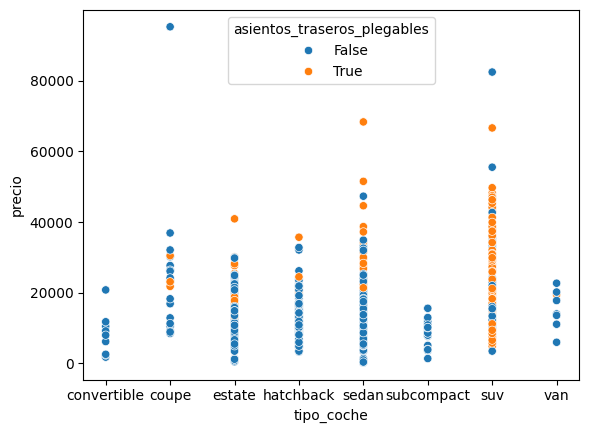

In [35]:
sns.scatterplot(x="tipo_coche", y="precio", hue="asientos_traseros_plegables", data=df_cars)

In [37]:
df_cars["año"] = pd.to_datetime(df_cars["fecha_registro"]).dt.year

In [39]:
df_cars.head()

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta,anio,año
0,BMW,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01,2012.0,2012.0
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01,NaN,NaN
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01,2012.0,2012.0
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01,NaN,NaN
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01,NaN,NaN


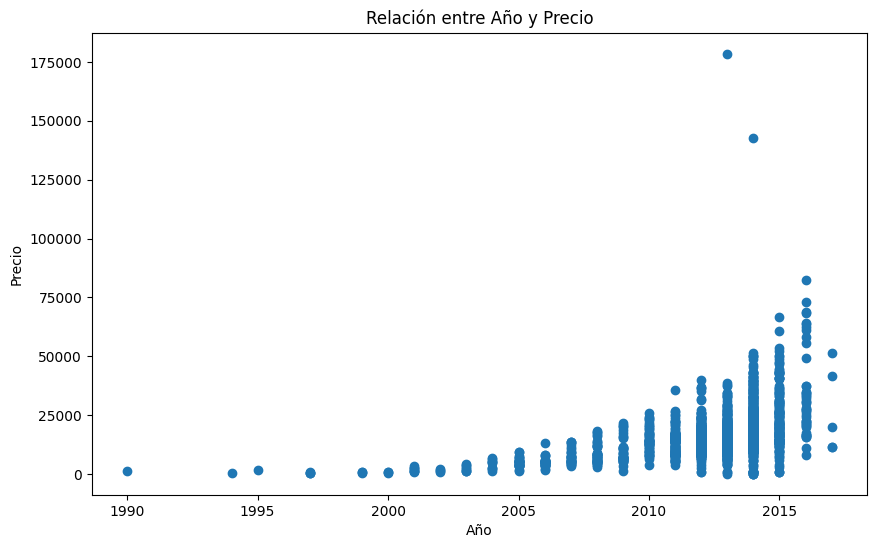

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df_cars["anio"], df_cars["precio"])
plt.xlabel("Año")
plt.ylabel("Precio")
plt.title("Relación entre Año y Precio")
plt.show()